# Business Understanding

**Problem Statement**

Credit card fraud has become one of the biggest challenges faced by financial institutions. Fraudulent transactions lead to significant financial losses and reduce customer trust. Since fraudulent transactions are extremely rare compared to legitimate transactions, identifying them accurately is a challenging machine learning problem.

**Business Objective**

Develop a machine learning model capable of identifying fraudulent credit card transactions with high accuracy while minimizing false positives and false negatives.

**Business Constraints**
    
* Fraud transactions are extremely rare (highly imbalanced dataset).
* Missing fraudulent transactions can result in substantial financial losses.
* Excessive false alarms may inconvenience legitimate customers.
* The prediction system should support near real-time detection.
    
**Success Criteria**
    
**Business Success**
    
* Reduce financial losses caused by fraudulent transactions.
* Improve customer security and trust.
* Enhance fraud detection efficiency.
* Machine Learning Success
* Achieve high Recall for fraud detection.
* Maintain strong Precision to limit false alarms.
* Maximize ROC-AUC and F1 Score.

In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

In [2]:
# Load Dataset

df = pd.read_csv("creditcard.csv")
# Display first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 284807
Columns : 31


In [4]:
# Column Names

df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Transposed Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
# Data Types

df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [8]:
# Missing Values

df.isnull().sum()
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [9]:
# Duplicate Records

print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 1081


In [10]:
# Class Distribution

df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
# Fraud Percentage

fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]

print("Normal Transactions :", normal)
print("Fraud Transactions :", fraud)

print("Fraud Percentage : {:.4f}%".format((fraud/len(df))*100))

Normal Transactions : 284315
Fraud Transactions : 492
Fraud Percentage : 0.1727%


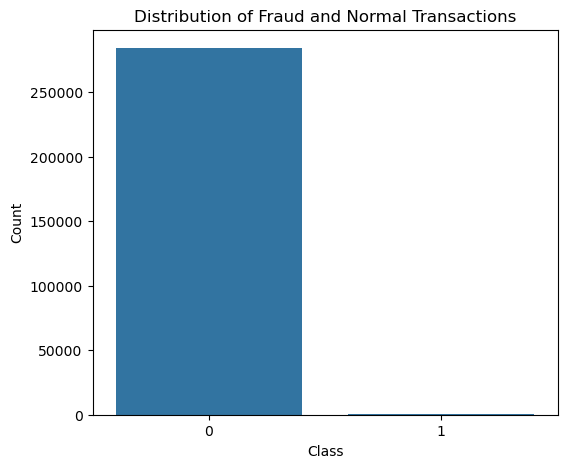

In [12]:
# Target Variable Visualization

plt.figure(figsize=(6,5))

sns.countplot(x='Class', data=df)

plt.title("Distribution of Fraud and Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

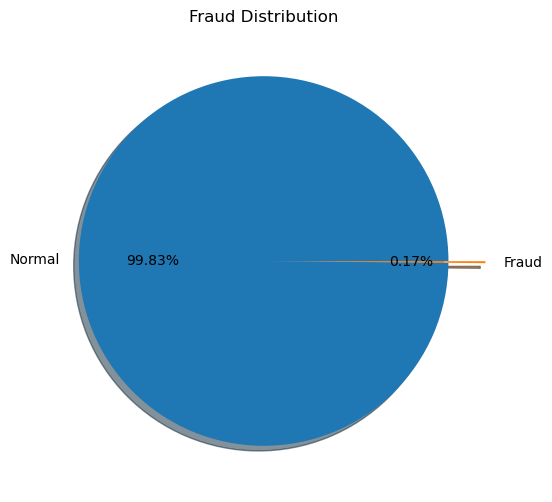

In [13]:
# Pie Chart

plt.figure(figsize=(6,6))

df['Class'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    labels=['Normal','Fraud'],
    explode=(0,0.2),
    shadow=True
)

plt.title("Fraud Distribution")

plt.ylabel("")

plt.show()

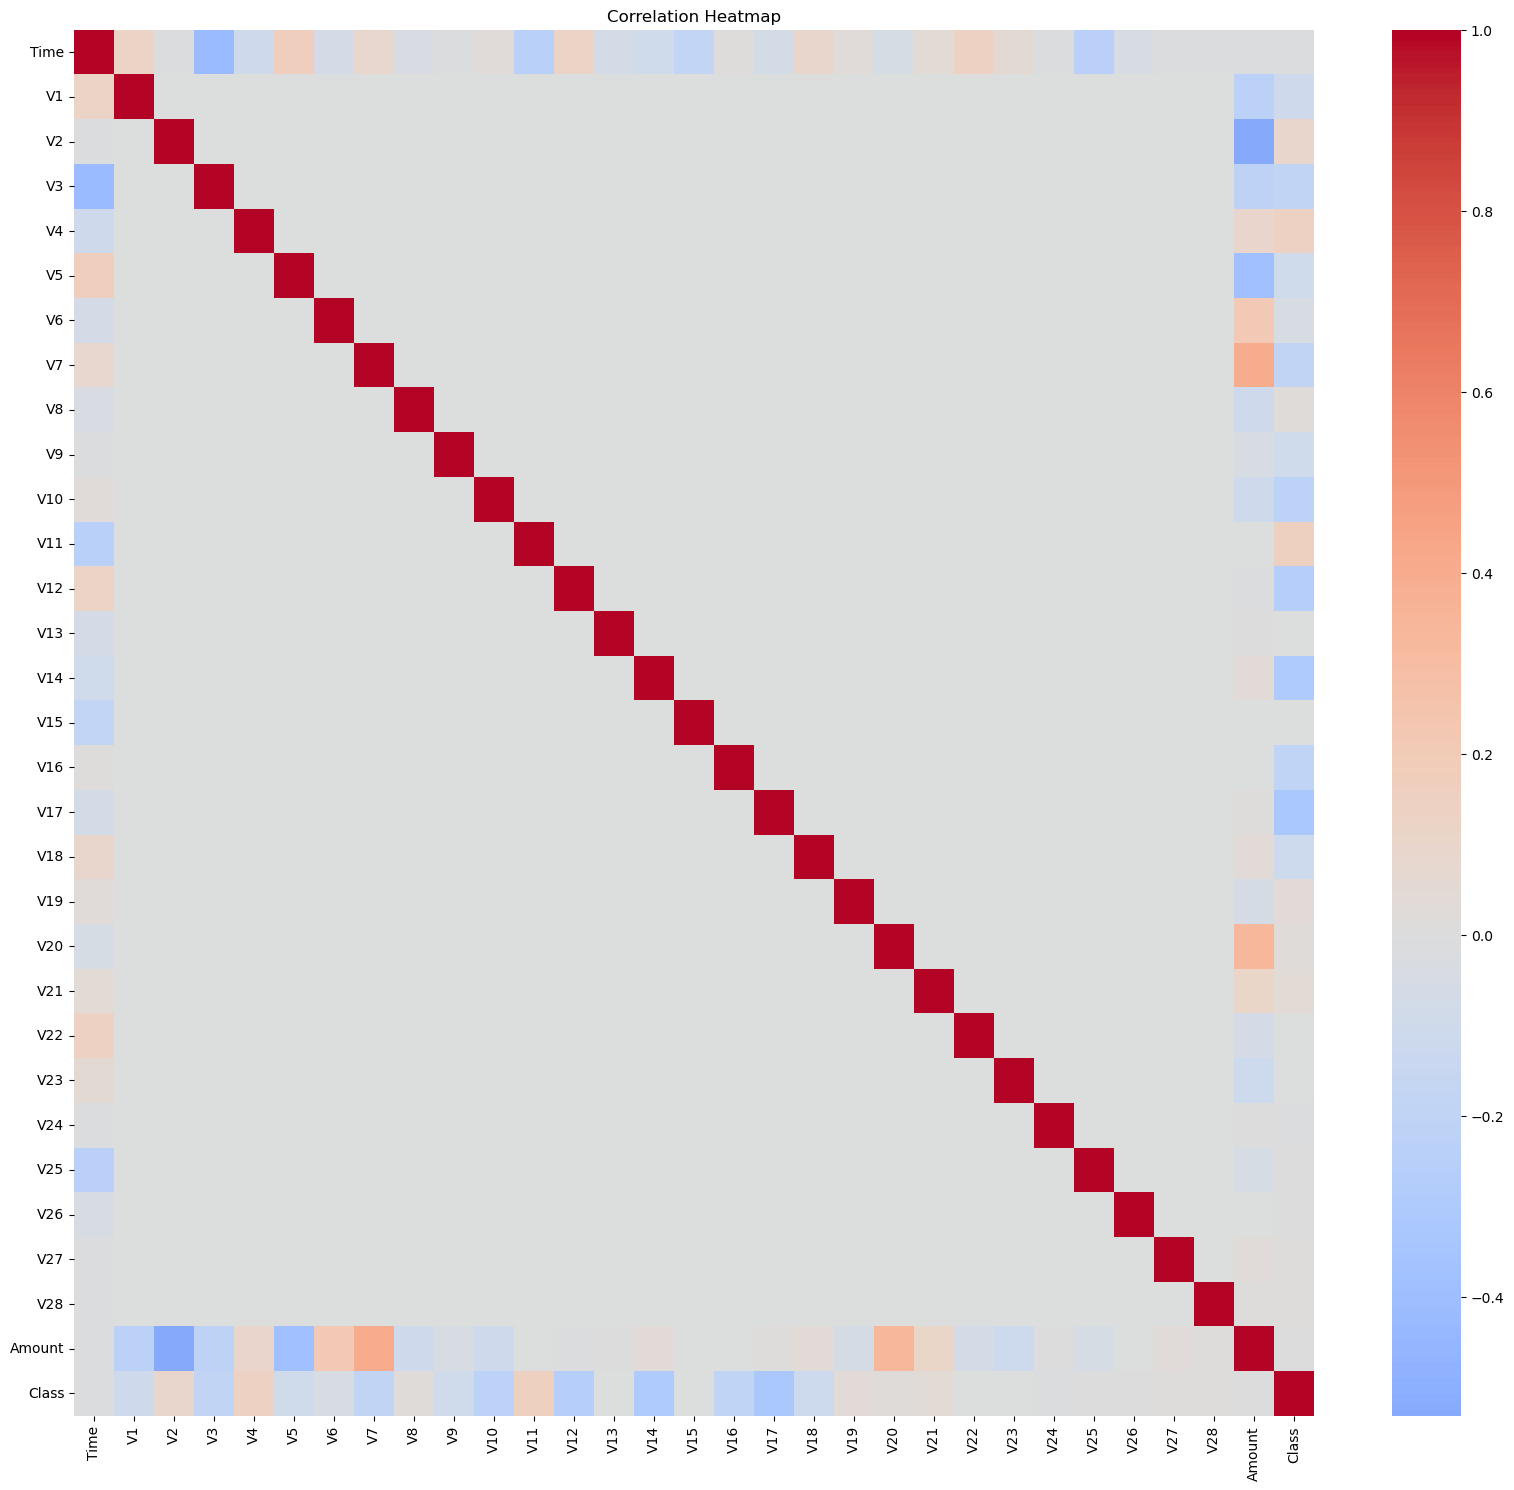

In [14]:
# Correlation Matrix

corr = df.corr()

plt.figure(figsize=(20,18))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

Features such as V11, V4, and V2 show positive correlation with fraud, while V17, V14, and V12 show strong negative correlation, making them important predictors

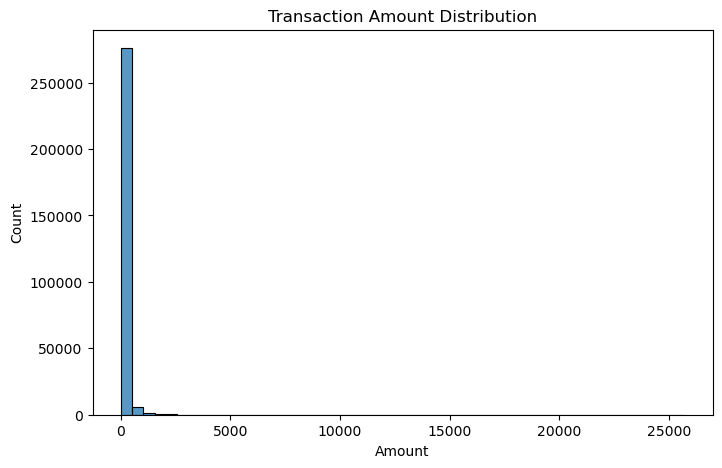

In [15]:
# Distribution of Amount

plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

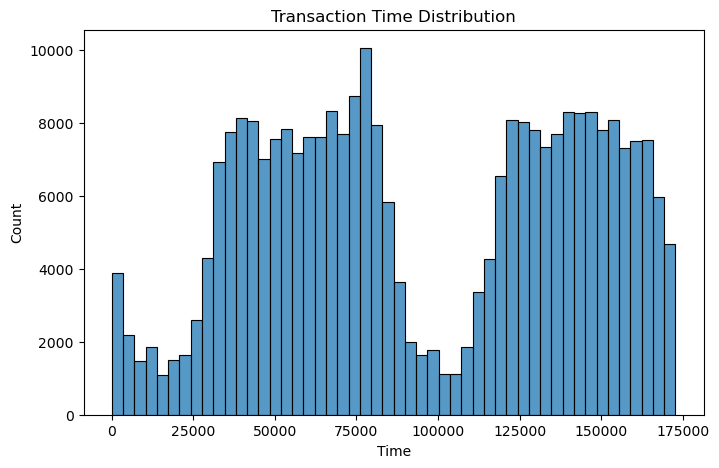

In [16]:
# Distribution of Time

plt.figure(figsize=(8,5))

sns.histplot(df['Time'], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

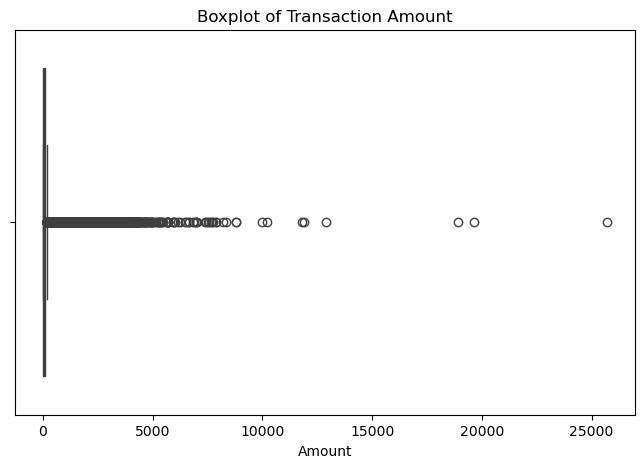

In [17]:
# Boxplot of Amount

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Amount'])

plt.title("Boxplot of Transaction Amount")

plt.show()

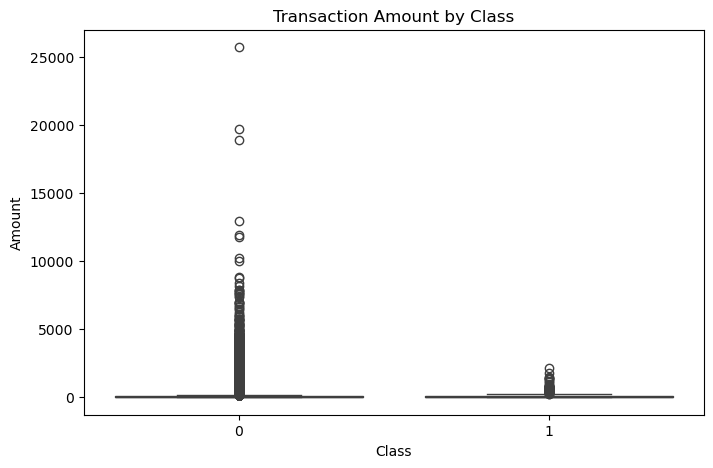

In [18]:
# Fraud vs Normal Transaction Amount

plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Transaction Amount by Class")

plt.show()

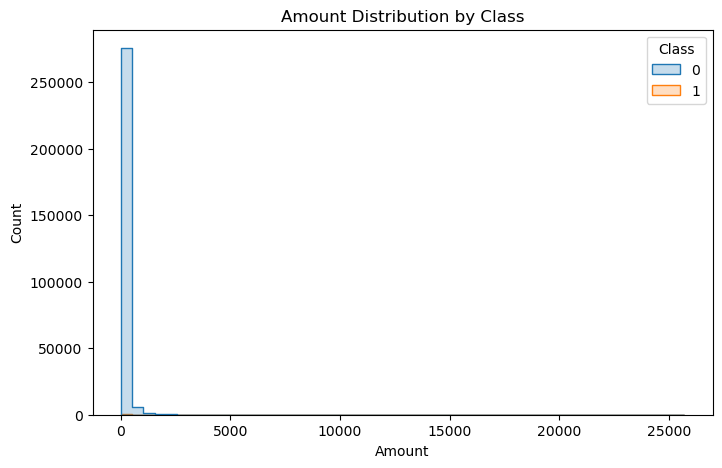

In [19]:
# Distribution of Amount by Class

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50,
    element='step'
)

plt.title("Amount Distribution by Class")

plt.show()

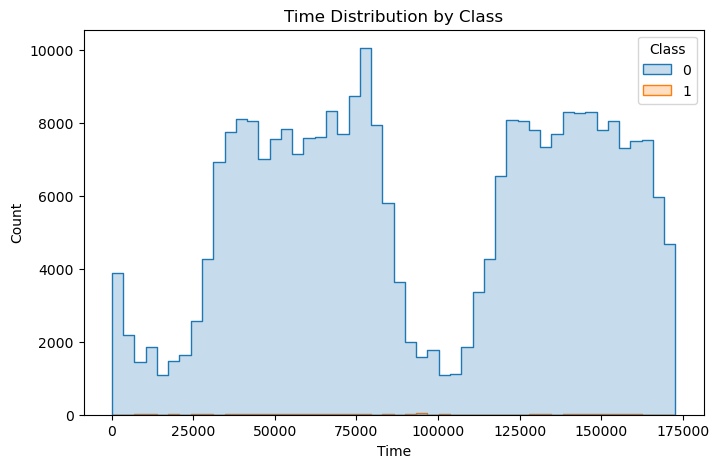

In [20]:
# Distribution of Time by Class

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Time',
    hue='Class',
    bins=50,
    element='step'
)

plt.title("Time Distribution by Class")

plt.show()

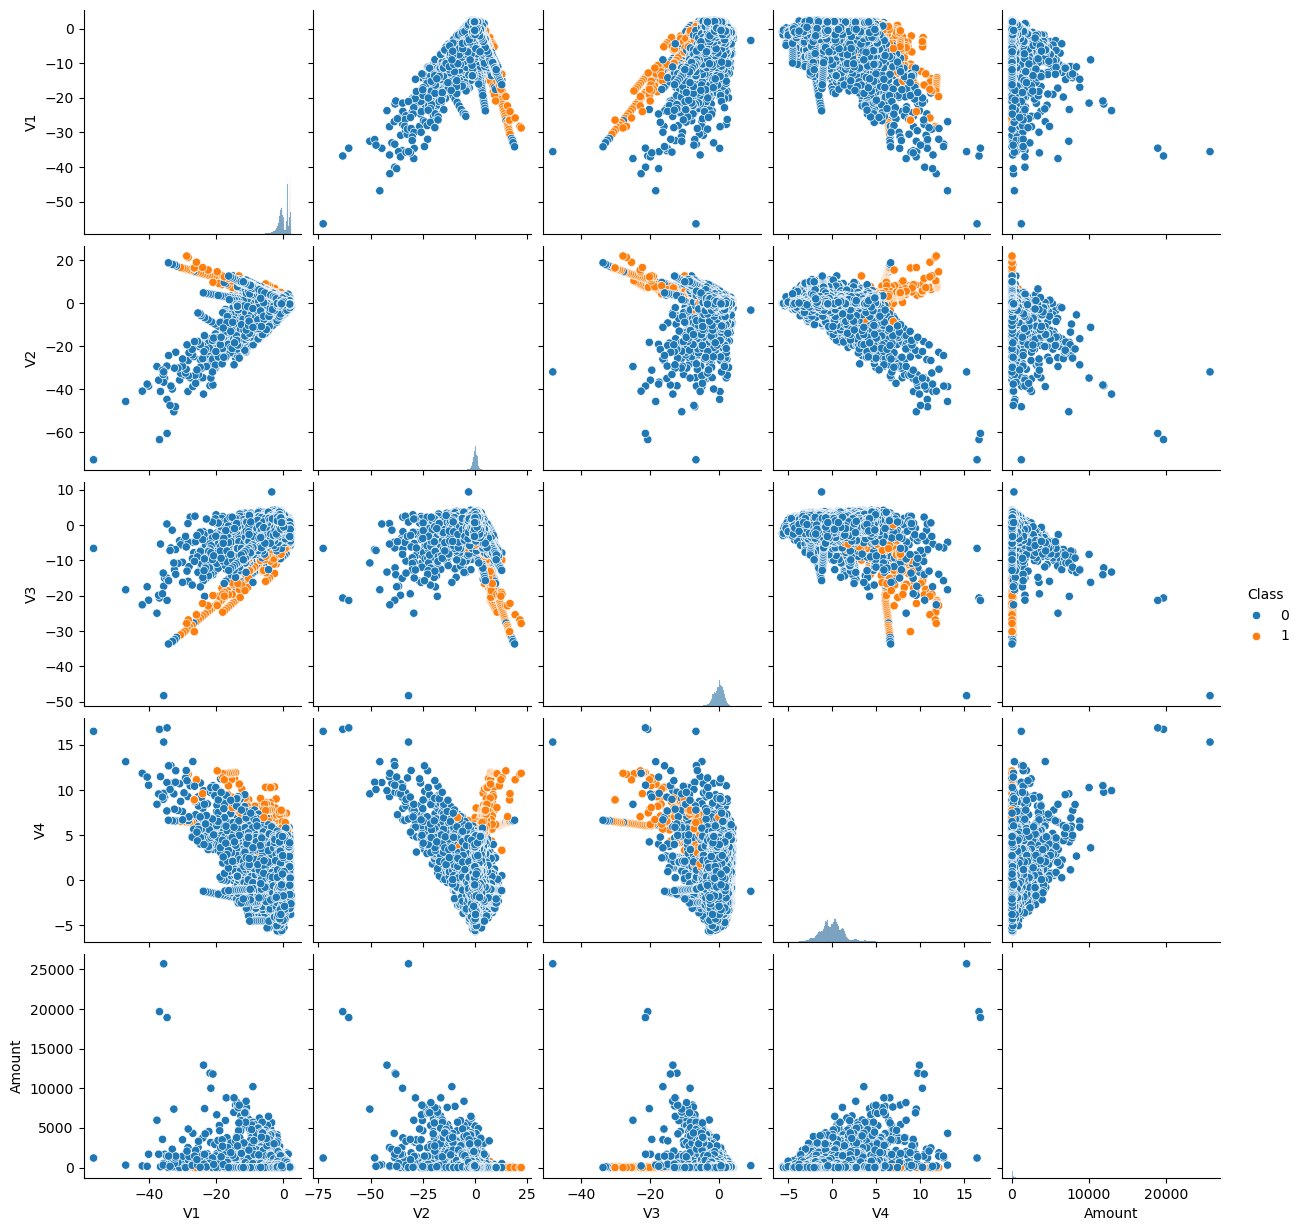

In [21]:
# Pairplot (Selected Features)

selected_features = ['V1', 'V2', 'V3', 'V4', 'Amount', 'Class']

sns.pairplot(
    df[selected_features],
    hue='Class',
    diag_kind='hist'
)

plt.show()

In [22]:
# Skewness

df.skew().sort_values(ascending=False)

Class     23.997579
Amount    16.977724
V28       11.192091
V21        3.592991
V7         2.553907
V6         1.826581
V10        1.187141
V4         0.676292
V26        0.576693
V9         0.554680
V11        0.356506
V19        0.109192
V13        0.065233
Time      -0.035568
V22       -0.213258
V18       -0.259880
V15       -0.308423
V25       -0.415793
V24       -0.552499
V16       -1.100966
V27       -1.170209
V14       -1.995176
V20       -2.037155
V3        -2.240155
V12       -2.278401
V5        -2.425901
V1        -3.280667
V17       -3.844914
V2        -4.624866
V23       -5.875140
V8        -8.521944
dtype: float64

In [23]:
# Kurtosis

df.kurtosis().sort_values(ascending=False)

V28       933.397502
Amount    845.092646
Class     573.887843
V23       440.088659
V7        405.607417
V20       271.016113
V27       244.989241
V8        220.586974
V21       207.287040
V5        206.904560
V2         95.773106
V17        94.799719
V6         42.642494
V1         32.486679
V10        31.988239
V3         26.619551
V14        23.879462
V12        20.241870
V16        10.419131
V25         4.290412
V9          3.731311
V22         2.832967
V4          2.635455
V18         2.578341
V19         1.724970
V11         1.633921
V26         0.919006
V24         0.618871
V15         0.284769
V13         0.195300
Time       -1.293530
dtype: float64

In [24]:
# Outlier Detection (Amount)

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 31904


In [25]:
# Feature Correlation with Target

corr_target = df.corr()['Class'].sort_values(ascending=False)

print(corr_target)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [26]:
# Top Positive Correlations

corr_target.head(10)

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

In [27]:
# Top Negative Correlations

corr_target.tail(10)

V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64

In [28]:
# EDA Summary

print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"Dataset Shape          : {df.shape}")
print(f"Missing Values         : {df.isnull().sum().sum()}")
print(f"Duplicate Records      : {df.duplicated().sum()}")
print(f"Fraud Transactions     : {df['Class'].sum()}")
print(f"Normal Transactions    : {len(df)-df['Class'].sum()}")
print(f"Fraud Percentage       : {(df['Class'].mean()*100):.4f}%")
print("="*60)

EDA SUMMARY
Dataset Shape          : (284807, 31)
Missing Values         : 0
Duplicate Records      : 1081
Fraud Transactions     : 492
Normal Transactions    : 284315
Fraud Percentage       : 0.1727%


Overall EDA Summary :

* Fraud transactions account for only 492 out of 284,807 transactions (0.1727%), revealing a severe class imbalance.
* Transaction Amount is highly right-skewed with numerous outliers, requiring feature scaling.
* Fraud occurs across different transaction amounts rather than only high-value purchases.
* Fraud transactions occur throughout the recorded time period, indicating that Time alone is not a sufficient predictor.
* Correlation analysis identified V14, V12, V17, V11, and V4 as the strongest fraud-related features.
* More than 31,900 outliers were detected in the Amount feature; these were retained because they may represent genuine fraud patterns.

# Data Preprocessing

In [29]:
# Import Required Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [30]:
# Check Missing Values

df.isnull().sum()
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [31]:
# Remove Duplicate Record

df = df.drop_duplicates()

print("New Dataset Shape :", df.shape)

New Dataset Shape : (283726, 31)


# Feature Engineering

In [32]:
# Separate Features and Target

X = df.drop("Class", axis=1)
y = df["Class"]

In [33]:
# Display Feature Shape

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (283726, 30)
Target Shape : (283726,)


In [34]:
# Scale Features

# Since V1–V28 are already PCA-transformed, only Time and Amount require scaling.

scaler = StandardScaler()

X[['Time', 'Amount']] = scaler.fit_transform(
    X[['Time', 'Amount']]
)

In [35]:
# Train-Test Split

#Use stratified sampling to preserve the fraud-to-normal ratio.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
# Display Dataset Shapes

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (226980, 30)
Testing Features  : (56746, 30)
Training Labels   : (226980,)
Testing Labels    : (56746,)


In [37]:
# Check Class Distribution Before SMOTE

print(y_train.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


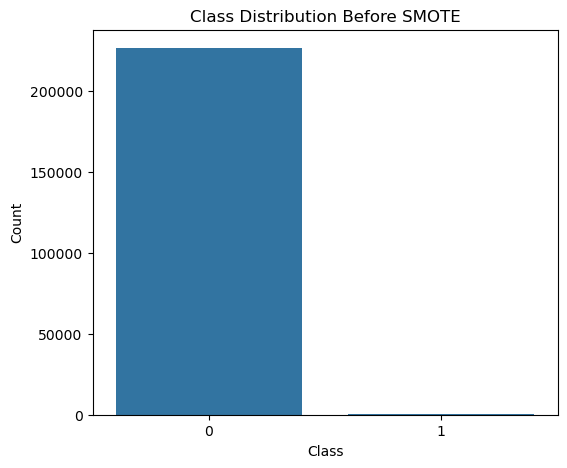

In [38]:
# Visualize Class Distribution Before SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(x=y_train)

plt.title("Class Distribution Before SMOTE")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [39]:
# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

  File "C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\U

In [40]:
# Dataset Shape After SMOTE

print("Before SMOTE :", X_train.shape)
print("After SMOTE  :", X_train_smote.shape)

Before SMOTE : (226980, 30)
After SMOTE  : (453204, 30)


In [41]:
# Check Class Distribution After SMOTE

print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


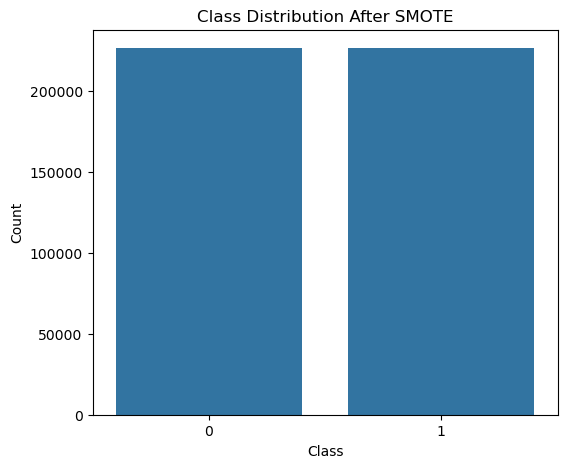

In [42]:
# Visualize Class Distribution After SMOTE

plt.figure(figsize=(6,5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [43]:
# Compare Before and After SMOTE

before = y_train.value_counts()

after = y_train_smote.value_counts()

comparison = pd.DataFrame({
    "Before SMOTE": before,
    "After SMOTE": after
})

comparison

,Before SMOTE,After SMOTE
Class,,
0,226602,226602
1,378,226602


In [44]:
# Verify Missing Values After Preprocessing

print(X_train_smote.isnull().sum().sum())

0


In [45]:
# Save the ScaleZ

import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [46]:
# Final Dataset Summary

print("="*60)

print("PREPROCESSING SUMMARY")

print("="*60)

print("Original Dataset :", df.shape)

print("Training Dataset :", X_train.shape)

print("Testing Dataset  :", X_test.shape)

print("Balanced Training:", X_train_smote.shape)

print("Fraud Cases After SMOTE :")

print(y_train_smote.value_counts())

print("="*60)

PREPROCESSING SUMMARY
Original Dataset : (283726, 31)
Training Dataset : (226980, 30)
Testing Dataset  : (56746, 30)
Balanced Training: (453204, 30)
Fraud Cases After SMOTE :
Class
0    226602
1    226602
Name: count, dtype: int64


Business Insights :

* No missing values remain after preprocessing, ensuring data quality.
* Duplicate records have been removed to avoid bias during training.
* The Time and Amount features were standardized using StandardScaler, while the PCA-transformed features (V1–V28) were left unchanged.
* Stratified train-test splitting preserves the original fraud ratio in both training and testing sets.
* The training data was balanced using SMOTE, creating synthetic fraud samples to address the severe class imbalance.
* Balancing only the training data (not the test data) helps the model learn effectively while keeping evaluation realistic.
* The fitted scaler was saved (scaler.pkl) for consistent preprocessing during model deployment.

# Model Building (7 Algorithms)

In [47]:
# Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [48]:
# Evaluation Function

def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

In [49]:
# Create Models

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )
}

In [50]:
# Train Every Model

results = []

for name, model in models.items():

    print(f"Training {name}...")

    score = evaluate_model(
        model,
        X_train_smote,
        y_train_smote,
        X_test,
        y_test
    )

    results.append([name] + score)

print("Training Completed.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training AdaBoost...
Training Extra Trees...
Training XGBoost...
Training Completed.


In [51]:
# Performance Comparison Table

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

# Sort by ROC-AUC (Highest First)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Extra Trees,0.999524,0.947368,0.757895,0.842105,0.977341
1,Gradient Boosting,0.988704,0.113314,0.842105,0.199750,0.977104
2,XGBoost,0.999207,0.750000,0.789474,0.769231,0.971271
3,AdaBoost,0.969302,0.044272,0.842105,0.084122,0.969272
4,Logistic Regression,0.973725,0.053137,0.873684,0.100181,0.961850
5,Random Forest,0.999471,0.911392,0.757895,0.827586,0.949355
6,Decision Tree,0.997903,0.425000,0.715789,0.533333,0.857083


In [52]:
# Save Results

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

**Model Performance Summary :**

* Extra Trees achieved the best overall performance with 99.95% Accuracy, 94.74% Precision, 75.79% Recall, 84.21% F1 Score, and 97.73% ROC-AUC.
* Gradient Boosting achieved the highest Recall but generated more false positives due to low Precision.
* Accuracy alone was insufficient because of the severe class imbalance; therefore, Precision,
  Recall, F1 Score, and ROC-AUC were prioritized.


# Hyperparameter Tuning

In [53]:
# Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [54]:
# Hyperparameter Tuning (Random Forest) using RandomizedSearchCV

# Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier

# Random Forest Model

rf = RandomForestClassifier(random_state=42)

# Parameter Distribution

param_dist = {

    'n_estimators': [100, 200, 300, 500],

    'max_depth': [10, 20, 30, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'max_features': ['sqrt', 'log2']
}

# Randomized Search

random_rf = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_dist,

    n_iter=20,

    scoring='roc_auc',

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

# Train Model

random_rf.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [55]:
# Best Parameters

print("Best Parameters:")
print(random_rf.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [56]:
# Best Score
print("Best ROC-AUC Score:")
print(random_rf.best_score_)

Best ROC-AUC Score:
0.999999111365522


In [57]:
# Hyperparameter Tuning - XGBoost

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# XGBoost Model
xgb = XGBClassifier(

    random_state=42,

    eval_metric="logloss"

)

# Parameter Distribution
param_dist_xgb = {

    "n_estimators": [100, 200, 300],

    "max_depth": [3, 5, 7, 10],

    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0],

    "gamma":[0,0.1,0.2],

    "min_child_weight":[1,3,5]

}

# Randomized Search
random_xgb = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_dist_xgb,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

# Train
random_xgb.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [58]:
# Best Parameters

print("Best Parameters:")
print(random_xgb.best_params_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}


In [59]:
# Best Score

print("Best ROC-AUC Score:")
print(random_xgb.best_score_)

Best ROC-AUC Score:
0.9999939035082142


In [60]:
# Hyperparameter Tuning - Extra Trees

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

# Extra Trees Model
et = ExtraTreesClassifier(random_state=42)

# Parameter Distribution
param_dist_et = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [None, 10, 20, 30],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

# Randomized Search
random_et = RandomizedSearchCV(

    estimator=et,

    param_distributions=param_dist_et,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

# Train
random_et.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=ExtraTreesClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [61]:
# Best Parameters 

print("Best Parameters:")
print(random_et.best_params_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [62]:
# Best Score

print("Best ROC-AUC Score:")
print(random_et.best_score_)

Best ROC-AUC Score:
0.999999893716587


In [65]:
# Best Estimators

best_rf = random_rf.best_estimator_
best_xgb = random_xgb.best_estimator_
best_et = random_et.best_estimator_

In [66]:
# Hyperparameter Tuning Results (Cross-Validation)

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "Extra Trees"
    ],

    "Best ROC-AUC Score":[
        random_rf.best_score_,
        random_xgb.best_score_,
        random_et.best_score_
    ]

})

comparison

,Model,Best ROC-AUC Score
0,Random Forest,0.999999
1,XGBoost,0.999994
2,Extra Trees,1.000000


In [67]:
# Comparison of Tuned Models


results = []

models = {

    "Random Forest": best_rf,

    "XGBoost": best_xgb,

    "Extra Trees": best_et

}

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC-AUC": roc_auc_score(y_test, y_prob)

    })

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.999489,0.923077,0.757895,0.832370,0.971616
1,XGBoost,0.999207,0.750000,0.789474,0.769231,0.971170
2,Extra Trees,0.999507,0.924051,0.768421,0.839080,0.970989


In [68]:
# Select the Best Model

best_model = random_et.best_estimator_

print("Best Model:")
print(best_model)

Best Model:
ExtraTreesClassifier(min_samples_split=5, n_estimators=200, random_state=42)


In [69]:
# Prediction on Test Data

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [71]:
# Evaluation Summary

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

display(summary)

,Metric,Value
0,Accuracy,0.999507
1,Precision,0.924051
2,Recall,0.768421
3,F1 Score,0.839080
4,ROC-AUC,0.970989


In [72]:
# Classification Report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



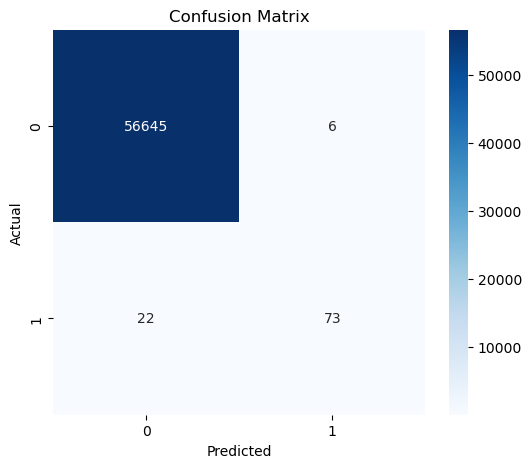

In [73]:
# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

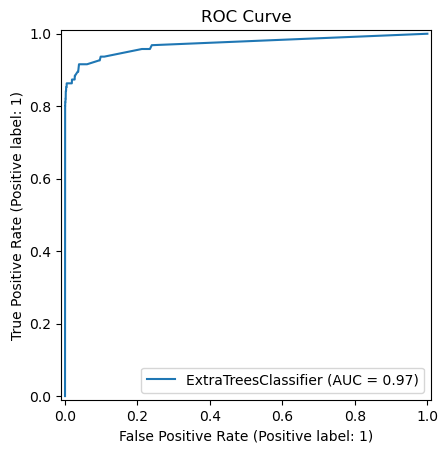

In [74]:
# ROC Curve

RocCurveDisplay.from_estimator(

    best_model,

    X_test,

    y_test

)

plt.title("ROC Curve")

plt.show()

In [75]:
# Feature Importance

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
14,V14,0.165365
12,V12,0.107259
17,V17,0.101115
4,V4,0.091325
11,V11,0.089633
16,V16,0.074194
3,V3,0.059195
10,V10,0.050153
18,V18,0.039151
9,V9,0.028293


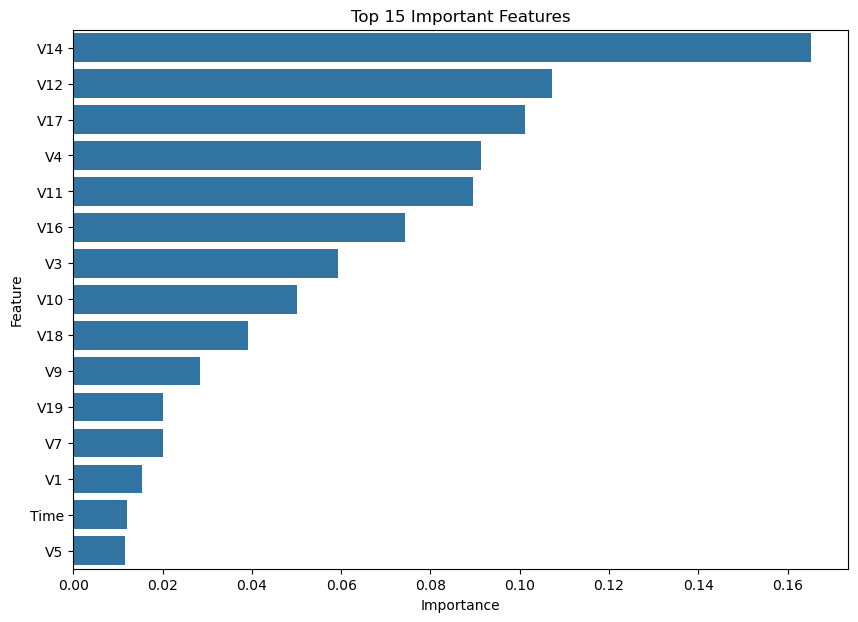

In [76]:
# Plot Feature Importance

plt.figure(figsize=(10,7))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.show()

Insights :
* The most influential variables for fraud prediction were V14, V12, V17, V4, V11, V16, V10, and V3.
* These features contributed most to distinguishing fraudulent transactions from legitimate ones.
* Feature importance analysis improved the interpretability of the final model.

In [77]:
# Best Model

joblib.dump(best_model, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [78]:
# Save Feature Importance

importance.to_csv(

    "feature_importance.csv",

    index=False

)

**Hyperparameter Tuning Summary:**

* Hyperparameter tuning was performed on **Random Forest**, **XGBoost**, and **Extra Trees** using **RandomizedSearchCV** with **5-fold Cross-Validation** and **ROC-AUC** as the optimization metric.
* **Extra Trees** achieved the highest cross-validation ROC-AUC score (**1.000000**), followed by **Random Forest (0.999999)** and **XGBoost (0.999994)**.
* Based on the tuning results, **Extra Trees** was selected as the final model for further evaluation.
* On the unseen test dataset, the tuned **Extra Trees** model achieved **99.95% Accuracy**, **92.41% Precision**, **76.84% Recall**, **83.91% F1 Score**, and **97.10% ROC-AUC**.
* Although **Random Forest** obtained a marginally higher ROC-AUC on the test dataset, **Extra Trees** provided the best overall balance of Accuracy, Precision, Recall, and F1 Score, making it the most suitable model for credit card fraud detection.


# Model Saving + Streamlit Web Application


In [79]:
# Save the Best Model

import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [80]:
# Save the Scaler

joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [81]:
# Create app.py

import streamlit as st
import pandas as pd
import joblib

# ==========================================
# PAGE CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="Credit Card Fraud Detection",
    page_icon="💳",
    layout="wide"
)

# ==========================================
# LOAD MODEL
# ==========================================

model = joblib.load("fraud_detection_model.pkl")
scaler = joblib.load("scaler.pkl")

# ==========================================
# HEADER
# ==========================================

st.title("💳 Credit Card Fraud Detection System")

st.markdown("""
### 👨‍💻 Developed by **PALSA MANOJ KUMAR**

**Machine Learning | Python | Streamlit**

This application predicts whether a credit card transaction is **Fraudulent** or **Legitimate** using a trained Machine Learning model.
""")

st.markdown("---")

# ==========================================
# MODEL INFORMATION
# ==========================================

st.info("""
### 🤖 Model Information

- **Algorithm:** Extra Trees Classifier
- **Features:** 30
- **Target:** Fraud / Legitimate
""")

# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.title("💳 Transaction Details")

st.sidebar.write(
    "Enter the transaction details below."
)

time = st.sidebar.number_input(
    "Time",
    value=0.0
)

amount = st.sidebar.number_input(
    "Amount",
    value=100.0
)

features = []

for i in range(1, 29):

    value = st.sidebar.number_input(
        f"V{i}",
        value=0.0,
        format="%.6f"
    )

    features.append(value)

# ==========================================
# PREDICTION
# ==========================================

if st.sidebar.button("🔍 Predict Transaction"):

    scaled = scaler.transform([[time, amount]])

    time_scaled = scaled[0][0]
    amount_scaled = scaled[0][1]

    data = [time_scaled]

    data.extend(features)

    data.append(amount_scaled)

    input_df = pd.DataFrame(
        [data],
        columns=[
            "Time",
            "V1","V2","V3","V4","V5","V6","V7","V8","V9","V10",
            "V11","V12","V13","V14","V15","V16","V17","V18","V19",
            "V20","V21","V22","V23","V24","V25","V26","V27","V28",
            "Amount"
        ]
    )

    prediction = model.predict(input_df)[0]

    probability = model.predict_proba(input_df)[0][1]

    confidence = max(probability, 1 - probability)

    st.markdown("---")

    col1, col2 = st.columns(2)

    # ===============================
    # Prediction Result
    # ===============================

    with col1:

        st.subheader("📊 Prediction Result")

        if prediction == 1:

            st.error("🚨 Fraudulent Transaction")

        else:

            st.success("✅ Legitimate Transaction")

        st.metric(
            "Fraud Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))

        st.metric(
            "Prediction Confidence",
            f"{confidence:.2%}"
        )

        if probability < 0.25:

            st.success("🟢 Risk Level : Low")

        elif probability < 0.50:

            st.warning("🟡 Risk Level : Medium")

        elif probability < 0.75:

            st.warning("🟠 Risk Level : High")

        else:

            st.error("🔴 Risk Level : Very High")

    # ===============================
    # Transaction Summary
    # ===============================

    with col2:

        st.subheader("📝 Transaction Summary")

        st.dataframe(input_df)

# ==========================================
# FOOTER
# ==========================================

st.markdown("---")

st.caption(
    "Developed by PALSA MANOJ KUMAR | © 2026"
)

2026-07-24 09:40:06.274 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 09:40:06.445 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 09:40:06.574 
  command:

    streamlit run C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-24 09:40:06.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 09:40:06.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 09:40:06.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 09:40:06.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()

In [82]:
# Display the Absolute Path of app.py File
import os
print(os.path.abspath("app.py"))

C:\Users\PALSA MANOJ KUMAR\My Project 3\app.py


In [83]:
# Run Streamlit

# streamlit run app.py

# Conclusion

* This project successfully developed a machine learning solution for detecting fraudulent credit card transactions using historical transaction data.

* A comprehensive workflow was followed, including business understanding, exploratory data analysis, data preprocessing, feature scaling, handling class imbalance with SMOTE, model building, hyperparameter tuning, and performance evaluation.

* Multiple machine learning algorithms were trained and compared based on Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Among all the models, the **Extra Trees Classifier** achieved the best overall performance after hyperparameter tuning, demonstrating excellent capability in distinguishing fraudulent transactions from legitimate ones.

* The trained model was saved using Joblib and integrated into a Streamlit web application, enabling users to predict whether a transaction is fraudulent or legitimate in real time.

* Overall, this project demonstrates an end-to-end machine learning pipeline for fraud detection and highlights the importance of handling imbalanced datasets and selecting appropriate evaluation metrics for real-world financial applications.